In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings


warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

In [ ]:
df = pd.read_csv('student_lifestyle_100k.csv')
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


# EDA

**Дубликаты (их нет, следовательно и их обработка не требуется)**

In [ ]:
print("Строк-дубликатов:", df[df.duplicated()].shape[0])

Строк-дубликатов: 0


**Анализ целевых переменных**

*CGPA*

In [ ]:
col = 'CGPA'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[col], bins=30)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df[col])
axes[1].set_ylabel('Значение')

print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median():.2f}")
print(f"Минимум: {df[col].min():.2f}")
print(f"Максимум: {df[col].max():.2f}")
print(f"Количество NULL: {df[col].isnull().sum()}")

Анализ: эта переменная распределена почти равномерно, если не учитывать значения до 2.0 и с 3.75, возможно они являются аномалиями, также есть три "пика" в пределах от 2.0 до 3.75, такое распределение может привести к тому, что модель обучится просто предсказывать среднее значение (так как при таком распределении отклонения от среднего будут уравновешивать друг друга, давая хорошие результаты метрик при низком качестве модели)

*Depression*

In [ ]:
val_count = df['Depression'].value_counts()
plt.pie(val_count.values, labels=val_count.index)
print(val_count)

Анализ: данная переменная имеет большой перевес в сторону False, что может доставить проблемы на этапе обучения модели, для корректной работы модели с данным признаком достаточно заменить False на 0 и True на 1.

**Анализ чиcловых признаков**

In [ ]:
num_cols = df.drop(["CGPA"],axis=1).select_dtypes(include='number').columns.tolist()
print("Числовые признаки:", num_cols)

Числовые признаки: ['Student_ID', 'Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']


*Student_ID*

Анализ: данный признак по сути представляет из себя порядковый номер записи в датасете, этот признак не несёт в себе полезной информации, и возможно даже будет опасен для корректной работы модели (так как модель может придать ему излишнее значение)

*Age*

In [ ]:
col = 'Age'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[col], bins=7)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df[col])
axes[1].set_ylabel('Значение')

print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median():.2f}")
print(f"Минимум: {df[col].min():.2f}")
print(f"Максимум: {df[col].max():.2f}")
print(f"Количество NULL: {df[col].isnull().sum()}")

Анализ: этот признак распределён почти равномерно, и является дискретным (вледствие чего количество bins было уменьшено, чтобы не было "дыр" в гистограмме). По сути этот признак является ранговым в какой-то степени.

*Sleep_Duration*

In [ ]:
col = 'Sleep_Duration'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[col], bins=20)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df[col])
axes[1].set_ylabel('Значение')

print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median():.2f}")
print(f"Минимум: {df[col].min():.2f}")
print(f"Максимум: {df[col].max():.2f}")
print(f"Количество NULL: {df[col].isnull().sum()}")

Анализ: распределение данного признака очень близко к нормальному, есть некоторое количество значений от 11 до 12, которые скорее всего являются аномалиями  

*Study_Hours*

In [ ]:
col = 'Study_Hours'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[col], bins=20)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df[col])
axes[1].set_ylabel('Значение')

print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median():.2f}")
print(f"Минимум: {df[col].min():.2f}")
print(f"Максимум: {df[col].max():.2f}")
print(f"Количество NULL: {df[col].isnull().sum()}")

Анализ распределние данного признака таже достаточно близко к нормальному, если не считать "хвоста" справа, возможно данные значения являются выбросами.

*Social_Media_Hours*

In [ ]:
col = 'Social_Media_Hours'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[col], bins=20)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df[col])
axes[1].set_ylabel('Значение')

print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median():.2f}")
print(f"Минимум: {df[col].min():.2f}")
print(f"Максимум: {df[col].max():.2f}")
print(f"Количество NULL: {df[col].isnull().sum()}")

Анализ: данный признак, как и предыдущий имеет близкое к нормальному распределение и "хвост" справа

*Physical_Activity*

In [ ]:
col = 'Physical_Activity'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[col], bins=30)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df[col])
axes[1].set_ylabel('Значение')

print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median():.2f}")
print(f"Минимум: {df[col].min():.2f}")
print(f"Максимум: {df[col].max():.2f}")
print(f"Количество NULL: {df[col].isnull().sum()}")

Анализ: этот признак распределён почти равномерно, не имеет ярко выраженных особенностей

*Stress_Level*

In [ ]:
col = 'Stress_Level'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[col], bins=8)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df[col])
axes[1].set_ylabel('Значение')

print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median():.2f}")
print(f"Минимум: {df[col].min():.2f}")
print(f"Максимум: {df[col].max():.2f}")
print(f"Количество NULL: {df[col].isnull().sum()}")

Анализ: распределение этого признака похоже на распределения Social_Media_Hours и Study_Hours, сам признак является дискретным. По сути этот признак является ранговым в какой-то степени.

**Анализ категориальных признаков**

*Gender*

In [ ]:
val_count = df['Gender'].value_counts()
plt.pie(val_count.values, labels=val_count.index)
print(val_count)

Анализ: данный признак распределён почти идеально равномерно, для корректной обработки данного признака моделью достаточно заменить Female на 0, а Male на 1

*Department*

In [ ]:
val_count = df['Department'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[1].pie(val_count.values, labels=val_count.index)
axes[0].bar(val_count.index, val_count.values, 0.5)

Анализ: этот признак имеет 5 уникальных значений, количества элементов каждого класса примерно равны, для обработки данного признака моделью удобнее всего будет использовать OneHot encoder

**Общий анализ переменных и признаков**

*Вывод из раздельного анализа признаков*

*   Данные распределены либо равномерно, либо нормально, исходя из чего можно предположить, что значения могли быть сгенерированны (вообще на kaggle написано, что датасет *симулирует* опрос, так что это вполне логично)
*   Вероятнее всего признаки Sleep_Duration, Study_Hours и Social_Media_Hours будут вместе коррелировать так как в сутках 24 часа
*   В датасете отсутствуют пропуски, а также значения медианы и среднего значения почти равны для каждого числового признака, что также указывает на сгенерированность данных (наверное)



*Суммарное время, описанное студентом*

In [ ]:
df['summary_time'] = df['Sleep_Duration'] + df["Study_Hours"] + df["Social_Media_Hours"] + df['Physical_Activity'] / 60
col = 'summary_time'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[col], bins=30)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df[col])
axes[1].set_ylabel('Значение')

print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median():.2f}")
print(f"Минимум: {df[col].min():.2f}")
print(f"Максимум: {df[col].max():.2f}")
print(f"Количество NULL: {df[col].isnull().sum()}")

df = df.drop(['summary_time'], axis=1)

Анализ: исходя из этих данных есть студенты, у которых 28 часов в сутках в среднем, и есть студенты, о жизни которых по сути почти нет информации (или данные о времени генерировались в отрыве от друг друга), ну а распределение как обычно нормальное.

*Анализ корреляций*

In [ ]:
numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr(method='pearson')
plt.figure(figsize=(8, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, square=True, linewidths=0.5)
plt.title(f'Correlation Heatmap', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Анализ: исходя из приведённой выше карты корреляции видно, что все корреляции вполне логины и понятны, полностью отсутствуют необъяснимые простой логикой связи (что также наталкивает на предположение о сгенерированности данных), также ни одна из корреляций не является достаточно большой.

*Анализ Scatter Matrix*

*Датасет без ранговых признаков*

In [ ]:
df_unranked = df.select_dtypes(include=[np.number]).drop(columns=["Age", "Stress_Level", "Student_ID"])

*Раскраска по Depression*

In [ ]:
a = pd.plotting.scatter_matrix(df_unranked,c=df['Depression'].apply(int),figsize = (20,20))

*Раскраска по Department*

In [ ]:
vals = list(df['Department'].value_counts().index)
a = pd.plotting.scatter_matrix(df_unranked,c=df['Department'].apply(lambda x: vals.index(x)),figsize = (20,20))

*Раскраска по Age*

In [ ]:
a = pd.plotting.scatter_matrix(df_unranked,c=df["Age"],figsize = (20,20))

*Раскраска по Stress_Level*

In [ ]:
a = pd.plotting.scatter_matrix(df_unranked,c=df["Stress_Level"],figsize = (20,20))

*Раскраска по Gender*

In [ ]:
a = pd.plotting.scatter_matrix(df_unranked,c=df["Gender"].apply(lambda x: x == "Male"),figsize = (20,20))

Анализ: исходя из данной матрицы можно заметить, что у признаков Study_Hours и Social_Media_Hours есть некоторые пороговые значения, после которых они оказвают влияние на CGPA (можно выделить в отдельный признак), также есть некоторое подобие порога в Sleep_Duration. Также хотелось бы отметить, что если раскрасить точки по Department, Gender и Age, то получится, что они распределены равномерно вообще везде, следовательно несут почти никакую полезную информацию. Исходя из первой матрицы также заметна связь CGPA с Depression и Sleep_Duration (большая плотность точек другого цвета).
Также заметны явные зависимости между Stress_Level и другими параметрами, но они никак не связанны с целевыми переменными.

*Отношение Deprssion к другим признакам*

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
vals = ["Stress_Level", "Age", "Department", "Gender"]
for l in range(len(vals)):
  val1 = df["Depression"].value_counts().index
  val2 = df[vals[l]].value_counts().index
  corr = [[sum((df["Depression"] == i) & (df[vals[l]] == j)) for i in val1] for j in val2]
  sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, square=True, linewidths=0.5, ax =axes[l])
  axes[l].set_title(vals[l])
plt.tight_layout()
plt.show()

Анализ: заметна граница на Stress_Level. Остальные признаки распределены почти равномерно (на Gender есть дисбаланс в 100-200 человек)

# Предобработка данных

**Обработка пропусков** не требуется ввиду их отсутствия

**Обработка некорректных значений**

In [ ]:
df = df[(df['Sleep_Duration'] + df["Study_Hours"] + df["Social_Media_Hours"] + df['Physical_Activity'] / 60) <= 24]
df = df[df["Sleep_Duration"] != 0]

Были убраны несоответствующие реальности значения, а именно студенты, у которых более 24 часов в сутках и те, которые в среднем не спят.

**Обработка выбросов**

"Выбросы", удаляемые ниже являются гипотетическими, влияние их удаления на качество работы модели будет рассмотрено в разделе "Качество моделей и влияние этапов предобработки"

In [ ]:
for col in ["Social_Media_Hours", "Study_Hours", "Sleep_Duration"]:
      Q1 = df[col].quantile(0.25)
      Q3 = df[col].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      mask = ~((df[col] < lower_bound) | (df[col] > upper_bound))
      df = df[mask]
df.reset_index(drop=True, inplace=True)

**Кодирование категориальных признаков и переменных**

In [ ]:
df["Gender"] = df["Gender"].apply(lambda x: int(x == "Male"))
df["Depression"] = df["Depression"].apply(lambda x: int(x))

df = pd.get_dummies(df, columns=["Department"], prefix=["Department"])
df.drop(columns=["Department_Business"], inplace = True)
for post in ["Arts", "Engineering", "Medical", "Science"]:
  df["Department_" + post] = df["Department_" + post].apply(int)

df.head()

,Student_ID,Age,Gender,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Department_Arts,Department_Engineering,Department_Medical,Department_Science
0,1001,22,0,3.50,7.3,3.3,3.4,114,5,0,0,0,0,1
1,1002,20,1,2.72,5.5,7.2,6.0,142,2,0,0,1,0,0
2,1003,20,1,3.01,5.4,2.3,1.8,137,3,0,0,0,1,0
3,1004,21,1,3.63,8.1,2.0,4.6,130,3,0,0,1,0,0
4,1005,19,1,3.14,6.8,2.6,4.3,4,6,0,1,0,0,0


**Работа с дисбалансом классов (использовалось при работе с Depression)**

*Upsampling* (не используется)

In [ ]:
df_upsampl = df[df["Depression"] == 1]
df = pd.concat([df, df_upsampl, df_upsampl, df_upsampl, df_upsampl, df_upsampl,
                df_upsampl], ignore_index=True)

*Downsampling*

In [ ]:
df_downsampl = df[(df["Depression"] == 0) & (df["Student_ID"] % 9 == 0)]
df = pd.concat([df[df["Depression"] == 1], df_downsampl])

*Замечание:* эти способы изменения датасета являются импровизацией и могут быть некорректно сделаны.

# Отбор признаков и Feature_engineering

*Отброшенные признаки:*

*   Student_ID - является обычным номером записи в датасете, не несёт полезной информации и может быть опасен для корректной работы модели
* Age - исходя из анализа Scatter_Matrix и того, что при обучении моделей этот признак не получал почти никакого значения
* Department - аналогично Age
* Gender - аналогично Age


In [ ]:
df.drop(columns=["Student_ID"],inplace=True)

In [ ]:
df.drop(columns=["Age", "Department_Arts", "Department_Engineering", "Department_Medical",
                 "Department_Science"], inplace=True)

In [ ]:
df.drop(columns=["Gender"], inplace=True)

*Новые признаки* (для линейной регрессии)

In [ ]:
df["Study_Hours*"] = 2 ** (df["Study_Hours"] - 7)
df["Social_Media_Hours*"] = 2 ** (df["Social_Media_Hours"] - 5)
df["Study_Hours_barrier"] = (df["Study_Hours"] > 7).astype(int)
df["Social_Media_Hours_barrier"] = (df["Social_Media_Hours"] > 5).astype(int)
df["Sleep_Duration_barrier"] = (df["Sleep_Duration"] > 4).astype(int)

In [ ]:
df.drop(columns=["Study_Hours", "Social_Media_Hours", "Sleep_Duration"], inplace=True)

*Новые признаки (для логистической регрессии)*

In [ ]:
df['CGPA_barrier'] = (df["CGPA"] > 2.5).astype(int)
df["Sleep_Duration_barrier"] = (df["Sleep_Duration"] > 4).astype(int)
df["Stress_Level_barrier"] = (df["Stress_Level"] < 5).astype(int)

In [ ]:
df.drop(columns=["Sleep_Duration", "CGPA"], inplace=True)

Эти признаки взяты из анализа Scatter Matrix'ов, также были эксперименты со степенями (через PolynomialFeatures), но они не завершились успехом, также оригинальные признаки убираются (проверено, что при них модель работает хуже), признаки со звёздочкой были сделаны экспоненциальными для того, чтобы они обладали таким же балансом, как и бинарные, но при этом были непрерывными, а не дискретными (чтобы вертикальные полосы на Residual Plot не были такими чёткими)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

pol = PolynomialFeatures()

y = df['CGPA']
X = df.drop(columns=['CGPA'])

X = pd.DataFrame(pol.fit_transform(X),columns=pol.get_feature_names_out())
X

,1,Age,Gender,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Age^-1,...,Depression^2,Depression Age^-1,Depression Stress_Level^-1,Depression Physical_Activity^-1,Age^-1^2,Age^-1 Stress_Level^-1,Age^-1 Physical_Activity^-1,Stress_Level^-1^2,Stress_Level^-1 Physical_Activity^-1,Physical_Activity^-1^2
0,1.0,22.0,0.0,7.3,3.3,3.4,114.0,5.0,0.0,0.043478,...,0.0,0.0,0.0,0.0,0.001890,0.007246,0.000378,0.027778,0.001449,0.000076
1,1.0,20.0,1.0,5.5,7.2,6.0,142.0,2.0,0.0,0.047619,...,0.0,0.0,0.0,0.0,0.002268,0.015873,0.000333,0.111111,0.002331,0.000049
2,1.0,20.0,1.0,5.4,2.3,1.8,137.0,3.0,0.0,0.047619,...,0.0,0.0,0.0,0.0,0.002268,0.011905,0.000345,0.062500,0.001812,0.000053
3,1.0,21.0,1.0,8.1,2.0,4.6,130.0,3.0,0.0,0.045455,...,0.0,0.0,0.0,0.0,0.002066,0.011364,0.000347,0.062500,0.001908,0.000058
4,1.0,19.0,1.0,6.8,2.6,4.3,4.0,6.0,0.0,0.050000,...,0.0,0.0,0.0,0.0,0.002500,0.007143,0.010000,0.020408,0.028571,0.040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98593,1.0,24.0,0.0,7.0,0.6,1.4,66.0,4.0,0.0,0.040000,...,0.0,0.0,0.0,0.0,0.001600,0.008000,0.000597,0.040000,0.002985,0.000223
98594,1.0,24.0,1.0,5.0,3.6,5.2,103.0,3.0,0.0,0.040000,...,0.0,0.0,0.0,0.0,0.001600,0.010000,0.000385,0.062500,0.002404,0.000092
98595,1.0,24.0,0.0,6.5,5.8,4.1,61.0,5.0,0.0,0.040000,...,0.0,0.0,0.0,0.0,0.001600,0.006667,0.000645,0.027778,0.002688,0.000260
98596,1.0,19.0,1.0,6.1,4.8,4.9,116.0,4.0,0.0,0.050000,...,0.0,0.0,0.0,0.0,0.002500,0.010000,0.000427,0.040000,0.001709,0.000073


In [ ]:
for feature in ["Age", "Stress_Level", "Physical_Activity"]:
  df[feature + "^-1"] = (df[feature].astype(np.float64)+1) ** -1

**Датасет с новыми признаками**

In [ ]:
df.head()

,Age,Gender,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Study_Hours^-1,Social_Media_Hours^-1,Sleep_Duration^-1
0,22,0,3.50,7.3,3.3,3.4,114,5,0,0.303030,0.294118,0.136986
1,20,1,2.72,5.5,7.2,6.0,142,2,0,0.138889,0.166667,0.181818
2,20,1,3.01,5.4,2.3,1.8,137,3,0,0.434783,0.555556,0.185185
3,21,1,3.63,8.1,2.0,4.6,130,3,0,0.500000,0.217391,0.123457
4,19,1,3.14,6.8,2.6,4.3,4,6,0,0.384615,0.232558,0.147059


# Анализ новых признаков

*Study_Hours**

In [ ]:
col = "Study_Hours*"
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[col], bins=30)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df[col])
axes[1].set_ylabel('Значение')

print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median():.2f}")
print(f"Минимум: {df[col].min():.2f}")
print(f"Максимум: {df[col].max():.2f}")
print(f"Количество NULL: {df[col].isnull().sum()}")

*Social_Media_Hours**

In [ ]:
col = "Social_Media_Hours*"
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[col], bins=30)
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df[col])
axes[1].set_ylabel('Значение')

print(f"Среднее: {df[col].mean():.2f}")
print(f"Медиана: {df[col].median():.2f}")
print(f"Минимум: {df[col].min():.2f}")
print(f"Максимум: {df[col].max():.2f}")
print(f"Количество NULL: {df[col].isnull().sum()}")

Анализ: эти новые признаки распределены экспоненциально, как и ожидалось от формулы

*Барьерные признаки (приписка barrier в конце)*

In [ ]:
val_count = df['Study_Hours_barrier'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[1].pie(val_count.values, labels=val_count.index)
axes[0].bar(val_count.index, val_count.values, 0.5)

In [ ]:
val_count = df['Sleep_Duration_barrier'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[1].pie(val_count.values, labels=val_count.index)
axes[0].bar(val_count.index, val_count.values, 0.5)

In [ ]:
val_count = df['Social_Media_Hours_barrier'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[1].pie(val_count.values, labels=val_count.index)
axes[0].bar(val_count.index, val_count.values, 0.5)

In [ ]:
val_count = df['CGPA_barrier'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[1].pie(val_count.values, labels=val_count.index)
axes[0].bar(val_count.index, val_count.values, 0.5)

In [ ]:
val_count = df['Stress_Level_barrier'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[1].pie(val_count.values, labels=val_count.index)
axes[0].bar(val_count.index, val_count.values, 0.5)

Анализ: данные признаки распределены неравномерно в соответствии с видом графиков из Scatter Matrix, отдельно хотелось бы отметить, что распределение Sleep_Duration_Barrier инвертированно

# Разделение данных на выборки и масштабирование

**Регрессия (предсказание CGPA)**

In [ ]:
from sklearn.model_selection import train_test_split

y = df['CGPA']
X = df.drop(columns=['CGPA'])

Разделение данных - 80 - обучение, 10 - тест, 10 - валидация.

**Классификация (предсказание Depression)**

In [ ]:
from sklearn.model_selection import train_test_split

y = df['Depression']
X = df.drop(columns=['Depression'])

**Разделение данных**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.11, random_state=42, shuffle=True)

Разделение данных - 80 - обучение, 10 - тест, 10 - валидация.

**Масштабирование**

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

Для оригинальных данных эффективнее использовать MinMaxScaler, так как они распределены симметрично, а StandardScaler хуже работает на симметричных данных, в то время как на изменённых данных для обоих моделей лучше показывает себя именно Standard

*Данные без дополнительных признаков*

In [ ]:
scaler = MinMaxScaler()

*Данные с дополнительными признаками*

In [ ]:
scaler = StandardScaler()

*Применение*

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение моделей

**Регрессия**

In [ ]:
from sklearn.linear_model import SGDRegressor

lr = SGDRegressor(random_state=42)
lr.fit(X_train_scaled, y_train)

SGDRegressor(random_state=42)

In [ ]:
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

**Логистическая регрессия** (для работы с эпохами был взят класс лог. регрессии, представленный на лекции)

*Класс*

In [ ]:
class LogisticRegressionCustom:
    """
    Логистическая регрессия с градиентным спуском.
    Функция активации: Сигмоида
    Функция потерь: Binary Cross-Entropy (Log Loss)
    """
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42, penalty='l2', alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.penalty = penalty  # 'l2' или None
        self.alpha = alpha      # Коэффициент регуляризации
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.loss_history_val = []

    def _initialize_parameters(self, n_features):
        """Инициализация весов и смещения"""
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def _sigmoid(self, z):
        """Сигмоидная функция активации"""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred_proba):
        """Вычисление Binary Cross-Entropy Loss"""
        epsilon = 1e-15
        y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)

        loss = -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

        if self.penalty == 'l2':
            loss += (self.alpha / (2 * len(y_true))) * np.sum(self.weights ** 2)

        return loss

    def fit(self, X, y, X_val, y_val):
        """Обучение модели градиентным спуском"""
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        self.loss_history = []

        for epoch in range(self.n_iterations):
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred_proba = self._sigmoid(linear_output)

            linear_output_val = np.dot(X_val, self.weights) + self.bias
            y_pred_proba_val = self._sigmoid(linear_output_val)

            loss = self._compute_loss(y, y_pred_proba)
            self.loss_history.append(loss)

            loss_val = self._compute_loss(y_val, y_pred_proba_val)
            self.loss_history_val.append(loss_val)

            error = y_pred_proba - y

            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            if self.penalty == 'l2':
                dw += (self.alpha / n_samples) * self.weights

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        """Предсказание класса (0 или 1)"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

*Обучение*

In [ ]:
n_epochs = 100

log_r = LogisticRegressionCustom(n_iterations=n_epochs, learning_rate=0.5)
log_r.fit(X_train_scaled, y_train, X_val_scaled, y_val)

In [ ]:
threshold = 0.5
y_train_pred = log_r.predict(X_train_scaled, threshold=threshold)
y_test_pred = log_r.predict(X_test_scaled, threshold=threshold)

*Эксперименты с Learning_Rate и n_epochs* (во всех случаях количество эпох достаточно большое, так, чтобы можно было увидеть всё развитие модели)

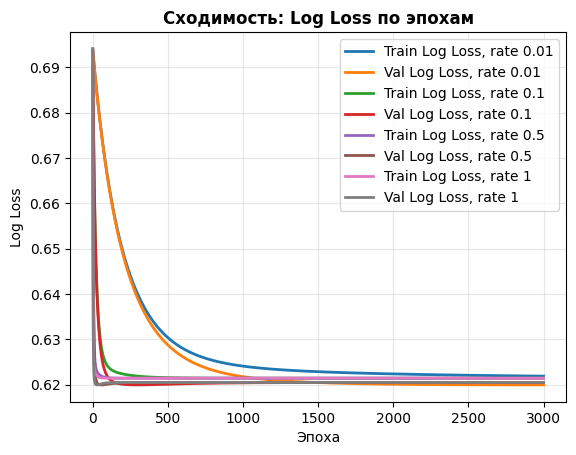

In [ ]:
n_epochs = 3000

learning_rates = [0.01, 0.1, 0.5, 1]

for learn_rate in learning_rates:
  log_r = LogisticRegressionCustom(n_iterations=n_epochs, learning_rate=learn_rate)
  log_r.fit(X_train_scaled, y_train, X_val_scaled, y_val)

  plt.plot(range(1, n_epochs + 1), log_r.loss_history, '-', linewidth=2, label=f'Train Log Loss, rate {learn_rate}')
  plt.plot(range(1, n_epochs + 1), log_r.loss_history_val, '-', linewidth=2, label=f'Val Log Loss, rate {learn_rate}')
  plt.xlabel('Эпоха', fontsize=10)
  plt.ylabel('Log Loss', fontsize=10)
  plt.title('Сходимость: Log Loss по эпохам', fontsize=12, fontweight='bold')
  plt.legend(loc='upper right')
  plt.grid(True, alpha=0.3)

Анализ: Исходя из графика выше можно сделать вывод, что в данном случае скорость обучения влияет только на скорость сходимости алгоритма, также из этого графика можно сделать вывод, что **модель не переобучается**, так как нет резкого роста val_loss при убывании train_loss

# Подсчёт метрик

**Метрики регрессии**

*Численные метрики*

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

print(f"R2 train: {r2_score(y_train,y_train_pred)}, test: {r2_score(y_test,y_test_pred)}")
print(f"MAE train: {mean_absolute_error(y_train,y_train_pred)}, test: {mean_absolute_error(y_test,y_test_pred)}")
print(f"MAPE train: {mean_absolute_percentage_error(y_train,y_train_pred)}, test: {mean_absolute_percentage_error(y_test,y_test_pred)}")
print(f"MSE train: {mean_squared_error(y_train,y_train_pred)}, test: {mean_squared_error(y_test,y_test_pred)}")

R2 train: 0.0711002757841428, test: 0.06782544345617525
MAE train: 0.44046151648865195, test: 0.4417550625349647
MAPE train: 0.16064483848333966, test: 0.16111143091430644
MSE train: 0.26277472736319557, test: 0.263211795453896


Анализ: исходя из данных метрик можно сделать вывод, что модель по сути предсказывает среднее значение переменной (так как R2 низкий), при этом другие метрики выглядят нормально, так как распределение CGPA равномерное, а значит значения с разных краёв балансируют друг друга.

*Визуальный анализ*

In [ ]:
from sklearn.model_selection import learning_curve

fig = plt.figure(figsize=(16, 16))

train_sizes, train_scores, val_scores = learning_curve(
    lr, X_train_scaled, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="r2",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1 = plt.subplot(3, 2, 1)
ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train R²', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val R²', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
ax1.set_ylabel('R² Score', fontsize=10)
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = plt.subplot(3, 2, 2)
ax2.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='black', s=20, color='purple')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальный прогноз')
ax2.set_xlabel('Фактическое значение', fontsize=10)
ax2.set_ylabel('Предсказанное значение', fontsize=10)
ax2.set_title('Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 2, 3)
residuals = y_test - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.5, edgecolors='black', s=20, color='orange')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Предсказанное значение', fontsize=10)
ax3.set_ylabel('Остатки (факт - предсказание)', fontsize=10)
ax3.set_title('Residual Plot (Test)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(3, 2, 4)
sns.histplot(residuals, bins=50, kde=True, ax=ax4, color='skyblue', edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', lw=2)
ax4.set_xlabel('Значение остатка', fontsize=10)
ax4.set_ylabel('Частота', fontsize=10)
ax4.set_title('Распределение остатков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

ax5 = plt.subplot(3, 2, 5)
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coef': lr.coef_
})
coefficients = coefficients.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False)

colors = ['green' if c > 0 else 'red' for c in coefficients['coef']]
bars = ax5.barh(coefficients['feature'], coefficients['coef'], color=colors, edgecolor='black')
ax5.set_xlabel('Значение коэффициента', fontsize=10)
ax5.set_title('Важность признаков', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
ax5.axvline(x=0, color='black', lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)
print()

Анализ: исходя из графиков выше можно сделать тот же самый вывод, что и из метрик: модель обучается предсказывать среднее значение, теряя зависимости (видны явные паттерны в Residual Plot). При этом важность признаков распределна вполне логично (больше учёбы -> больше успеваемость и т.д.).
Отдельно хотелось бы отметить то, что вертикальные линейные паттерны в Residual Plot вероятнее всего появились из-за слишком большого бинарных признаков, вследствие чего предсказанные значения расположены как ступени.

**Метрики классификации**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

print(f"F1 train: {f1_score(y_train,y_train_pred)}, test: {f1_score(y_test,y_test_pred)}")
print(f"Precision train: {precision_score(y_train,y_train_pred)}, test: {precision_score(y_test,y_test_pred)}")
print(f"Recall train: {recall_score(y_train,y_train_pred)}, test: {recall_score(y_test,y_test_pred)}")
print(f"Accuracy train: {accuracy_score(y_train,y_train_pred)}, test: {accuracy_score(y_test,y_test_pred)}")

F1 train: 0.31591519856673633, test: 0.31737545565006076
Precision train: 0.20790310479116797, test: 0.208893154190659
Recall train: 0.6575141242937853, test: 0.660262891809909
Accuracy train: 0.7128156623210867, test: 0.7151115618661258


Анализ: при использовании неизменного датасета (без upsampling'a или downsampling'a) модель по сути просто обучается предсказывать самый частый класс, при изменении соотношения классов значения метрик кроме accuracy начинают расти. Также хотелось бы отметить, что для корректности измерения метрик нужно применять обученную на изменённом датасете модель к данным из оригинального датасета (до upsampling'a или downsampling'a)

*Визуальный анализ*

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

fig = plt.figure(figsize=(16, 14))

ax1 = plt.subplot(2, 2, 1)
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_pred):.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('FP Rate')
ax1.set_ylabel('TP Rate')
ax1.set_title('ROC Curve (Test)')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 2, 2)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Предсказанный класс', fontsize=10)
ax2.set_ylabel('Фактический класс', fontsize=10)
ax2.set_title('Confusion Matrix (Test)')
ax2.set_xticklabels(['Negative (0)', 'Positive (1)'])
ax2.set_yticklabels(['Negative (0)', 'Positive (1)'])

ax3 = plt.subplot(2, 2, 3)
weights_df = pd.DataFrame({
    'feature': X.columns,
    'weight': log_r.weights
})
weights_df = weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False)

colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
bars = ax3.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
ax3.set_xlabel('Значение коэффициента', fontsize=10)
ax3.set_title('Важность признаков')
ax3.grid(True, alpha=0.3, axis='x')
plt.setp(ax3.get_yticklabels(), fontsize=8)

Анализ: Зависимости, выявленные моделью вполне логичны, главной слабостью модели является предсказание 1 (Positive), так как этих данных не так много. Из необычных наблюдений классификатор, выдающий только один класс считается случайным, если оценивать его только по ROC-AUC

# Влияние этапов предобработки

**Регрессия**

Благодаря добавленным признакам R2 вырос в 2-2.5 раза (c 0.03 до 0.07), остальные почти не изменились, остались невыявленные зависимости, если судить по Residual Plot. Благодаря новым признакам модель стала чуть меньше предсказывать среднее значение. Влияние очистки выбросов и скалирования минорное (10^-5 от R2). Удаление лишних признаков положительно влияет на работоспособность модели.

**Логистическая регрессия**

Самой важной частью в предобработке данных был Downsampling, позволивший отучить модель от предсказвания только одного класса, также положительно повлияли новые признаки.

# Быстрые пайплайны

**Общий код**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler


warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

**Регрессия**

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import learning_curve

df = pd.read_csv('student_lifestyle_100k.csv')

# предобработка
df = df[(df['Sleep_Duration'] + df["Study_Hours"] + df["Social_Media_Hours"] + df['Physical_Activity'] / 60) <= 24]
df = df[df["Sleep_Duration"] != 0]

for col in ["Social_Media_Hours", "Study_Hours", "Sleep_Duration"]:
      Q1 = df[col].quantile(0.25)
      Q3 = df[col].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      mask = ~((df[col] < lower_bound) | (df[col] > upper_bound))
      df = df[mask]
df.reset_index(drop=True, inplace=True)

# работа с признаками
df["Depression"] = df["Depression"].apply(lambda x: int(x))

df.drop(columns=["Student_ID", "Age", "Department", "Gender"], inplace=True)

df["Study_Hours*"] = 2 ** (df["Study_Hours"] - 7)
df["Social_Media_Hours*"] = 2 ** (df["Social_Media_Hours"] - 5)
df["Study_Hours_barrier"] = (df["Study_Hours"] > 7).astype(int)
df["Social_Media_Hours_barrier"] = (df["Social_Media_Hours"] > 5).astype(int)
df["Sleep_Duration_barrier"] = (df["Sleep_Duration"] > 4).astype(int)

df.drop(columns=["Study_Hours", "Social_Media_Hours", "Sleep_Duration"], inplace=True)

# масштабирование + разделение на выборки
y = df['CGPA']
X = df.drop(columns=['CGPA'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.11, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# обучение + предсказание
lr = SGDRegressor(random_state=42)
lr.fit(X_train_scaled, y_train)

y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

# метрики
print(f"R2 train: {r2_score(y_train,y_train_pred)}, test: {r2_score(y_test,y_test_pred)}")
print(f"MAE train: {mean_absolute_error(y_train,y_train_pred)}, test: {mean_absolute_error(y_test,y_test_pred)}")
print(f"MAPE train: {mean_absolute_percentage_error(y_train,y_train_pred)}, test: {mean_absolute_percentage_error(y_test,y_test_pred)}")
print(f"MSE train: {mean_squared_error(y_train,y_train_pred)}, test: {mean_squared_error(y_test,y_test_pred)}")

# графики
fig = plt.figure(figsize=(16, 16))

train_sizes, train_scores, val_scores = learning_curve(
    lr, X_train_scaled, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="r2",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1 = plt.subplot(3, 2, 1)
ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train R²', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val R²', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
ax1.set_ylabel('R² Score', fontsize=10)
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = plt.subplot(3, 2, 2)
ax2.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='black', s=20, color='purple')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальный прогноз')
ax2.set_xlabel('Фактическое значение', fontsize=10)
ax2.set_ylabel('Предсказанное значение', fontsize=10)
ax2.set_title('Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 2, 3)
residuals = y_test - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.5, edgecolors='black', s=20, color='orange')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Предсказанное значение', fontsize=10)
ax3.set_ylabel('Остатки (факт - предсказание)', fontsize=10)
ax3.set_title('Residual Plot (Test)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(3, 2, 4)
sns.histplot(residuals, bins=50, kde=True, ax=ax4, color='skyblue', edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', lw=2)
ax4.set_xlabel('Значение остатка', fontsize=10)
ax4.set_ylabel('Частота', fontsize=10)
ax4.set_title('Распределение остатков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

ax5 = plt.subplot(3, 2, 5)
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coef': lr.coef_
})
coefficients = coefficients.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False)

colors = ['green' if c > 0 else 'red' for c in coefficients['coef']]
bars = ax5.barh(coefficients['feature'], coefficients['coef'], color=colors, edgecolor='black')
ax5.set_xlabel('Значение коэффициента', fontsize=10)
ax5.set_title('Важность признаков', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
ax5.axvline(x=0, color='black', lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)
print()

**Логистическая регрессия**

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

class LogisticRegressionCustom:
    """
    Логистическая регрессия с градиентным спуском.
    Функция активации: Сигмоида
    Функция потерь: Binary Cross-Entropy (Log Loss)
    """
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42, penalty='l2', alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.penalty = penalty  # 'l2' или None
        self.alpha = alpha      # Коэффициент регуляризации
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.loss_history_val = []

    def _initialize_parameters(self, n_features):
        """Инициализация весов и смещения"""
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def _sigmoid(self, z):
        """Сигмоидная функция активации"""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred_proba):
        """Вычисление Binary Cross-Entropy Loss"""
        epsilon = 1e-15
        y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)

        loss = -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

        if self.penalty == 'l2':
            loss += (self.alpha / (2 * len(y_true))) * np.sum(self.weights ** 2)

        return loss

    def fit(self, X, y, X_val, y_val):
        """Обучение модели градиентным спуском"""
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        self.loss_history = []

        for epoch in range(self.n_iterations):
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred_proba = self._sigmoid(linear_output)

            linear_output_val = np.dot(X_val, self.weights) + self.bias
            y_pred_proba_val = self._sigmoid(linear_output_val)

            loss = self._compute_loss(y, y_pred_proba)
            self.loss_history.append(loss)

            loss_val = self._compute_loss(y_val, y_pred_proba_val)
            self.loss_history_val.append(loss_val)

            error = y_pred_proba - y

            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            if self.penalty == 'l2':
                dw += (self.alpha / n_samples) * self.weights

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        """Предсказание класса (0 или 1)"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

df = pd.read_csv('student_lifestyle_100k.csv')

# предобработка
df = df[(df['Sleep_Duration'] + df["Study_Hours"] + df["Social_Media_Hours"] + df['Physical_Activity'] / 60) <= 24]
df = df[df["Sleep_Duration"] != 0]

for col in ["Social_Media_Hours", "Study_Hours", "Sleep_Duration"]:
      Q1 = df[col].quantile(0.25)
      Q3 = df[col].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      mask = ~((df[col] < lower_bound) | (df[col] > upper_bound))
      df = df[mask]
df.reset_index(drop=True, inplace=True)

# работа с признаками
df["Gender"] = df["Gender"].apply(lambda x: int(x == "Male"))
df["Depression"] = df["Depression"].apply(lambda x: int(x))

df_downsampl = df[(df["Depression"] == 0) & (df["Student_ID"] % 9 == 0)]
df_learn = pd.concat([df[df["Depression"] == 1], df_downsampl])

df.drop(columns=["Student_ID", "Age", "Department"], inplace=True)
df_learn.drop(columns=["Student_ID", "Age", "Department"], inplace=True)

df['CGPA_barrier'] = (df["CGPA"] > 2.5).astype(int)
df["Sleep_Duration_barrier"] = (df["Sleep_Duration"] > 4).astype(int)
df["Stress_Level_barrier"] = (df["Stress_Level"] < 5).astype(int)

df_learn['CGPA_barrier'] = (df_learn["CGPA"] > 2.5).astype(int)
df_learn["Sleep_Duration_barrier"] = (df_learn["Sleep_Duration"] > 4).astype(int)
df_learn["Stress_Level_barrier"] = (df_learn["Stress_Level"] < 5).astype(int)

df.drop(columns=["Sleep_Duration", "CGPA"], inplace=True)
df_learn.drop(columns=["Sleep_Duration", "CGPA"], inplace=True)



# масштабирование + разделение на выборки
y = df_learn['Depression']
X = df_learn.drop(columns=['Depression'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.11, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

n_epochs = 100

log_r = LogisticRegressionCustom(n_iterations=n_epochs, learning_rate=0.5)
log_r.fit(X_train_scaled, y_train, X_val_scaled, y_val)

y = df['Depression']
X = df.drop(columns=['Depression'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.11, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

threshold = 0.5
y_train_pred = log_r.predict(X_train_scaled, threshold=threshold)
y_test_pred = log_r.predict(X_test_scaled, threshold=threshold)

print(f"F1 train: {f1_score(y_train,y_train_pred)}, test: {f1_score(y_test,y_test_pred)}")
print(f"Precision train: {precision_score(y_train,y_train_pred)}, test: {precision_score(y_test,y_test_pred)}")
print(f"Recall train: {recall_score(y_train,y_train_pred)}, test: {recall_score(y_test,y_test_pred)}")
print(f"Accuracy train: {accuracy_score(y_train,y_train_pred)}, test: {accuracy_score(y_test,y_test_pred)}")

fig = plt.figure(figsize=(16, 14))

ax1 = plt.subplot(2, 2, 1)
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_pred):.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('FP Rate')
ax1.set_ylabel('TP Rate')
ax1.set_title('ROC Curve (Test)')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 2, 2)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Предсказанный класс', fontsize=10)
ax2.set_ylabel('Фактический класс', fontsize=10)
ax2.set_title('Confusion Matrix (Test)')
ax2.set_xticklabels(['Negative (0)', 'Positive (1)'])
ax2.set_yticklabels(['Negative (0)', 'Positive (1)'])

ax3 = plt.subplot(2, 2, 3)
weights_df = pd.DataFrame({
    'feature': X.columns,
    'weight': log_r.weights
})
weights_df = weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False)

colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
bars = ax3.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
ax3.set_xlabel('Значение коэффициента', fontsize=10)
ax3.set_title('Важность признаков')
ax3.grid(True, alpha=0.3, axis='x')
plt.setp(ax3.get_yticklabels(), fontsize=8)
print()